In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================================
#  SAPA — EKSPERIMEN "KEPALA JATUH" (fall / oleng / normal)
#  Stratified-Group 5-Fold CV + callbacks + history + metrik lengkap + efisiensi
# ----------------------------------------------------------------------------
#  Input : ntu_fall.npz  (keypoints [N,45,17,3], labels {0=normal,1=oleng,2=jatuh})
#  Output (ke MODEL_DIR, dibuat otomatis):
#     fall_head.pt              - bobot model FINAL (dilatih di SEMUA data)
#     fall_head.json            - konfigurasi + ringkasan hasil CV (utk inferensi/web)
#     fall_cv_folds.csv         - metrik tiap fold
#     fall_cv_history.csv       - history tiap epoch, tiap fold
#     fall_cv_summary.json      - mean±std lintas fold + confusion matrix OOF
#     fall_cv_curves.png        - grafik (metrik per-fold + learning curve)
#
#  Copy tiap "# ===== CELL N =====" ke satu cell Colab, jalankan berurutan. GPU disarankan.
#  NB: 5-fold = 5x waktu latih. Kalau lama, kecilkan EPOCHS atau N_FOLDS=3.
#
#  Metodologi (kenapa begini):
#   • 12 SENDI badan + (x,y) saja  -> NTU tak punya wajah; conf NTU sintetis.
#   • StratifiedGroupKFold          -> stratifikasi kelas SAMBIL menjaga performer utuh
#                                      (anti-kebocoran). Split by-performer + seimbang kelas.
#   • Out-Of-Fold (OOF)             -> tiap sampel diprediksi model yg TAK melatihnya
#                                      -> confusion matrix OOF = evaluasi jujur seluruh data.
#   • Callbacks: EarlyStopping, ModelCheckpoint(per fold), ReduceLROnPlateau,
#     GradClip, CSVLogger. Metrik: acc, balanced-acc, macroF1, weightedF1,
#     recall_jatuh, MCC, Cohen's kappa, + false-alarm. Plus baseline & efisiensi.
# ============================================================================


# ===== CELL 1: Import + Konfigurasi =====
import os, re, json, csv, time, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, matthews_corrcoef, cohen_kappa_score,
                             confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

BASE      = "/content/drive/MyDrive/Belajar AI/Compfest/Dataset"
NPZ_PATH  = f"{BASE}/preprocessed_2/ntu_fall.npz"
MODEL_DIR = f"{BASE}/models"; os.makedirs(MODEL_DIR, exist_ok=True)   # dibuat kalau belum ada

FALL_JOINTS  = list(range(5, 17))     # 12 sendi badan
USE_CHANNELS = 2                      # x,y saja
CLASS_NAMES  = ["normal", "oleng", "jatuh"]; N_CLASSES = 3
METRIC_COLS  = ["acc", "bal_acc", "macroF1", "weightedF1", "recall_jatuh", "mcc", "kappa"]

# hyperparameter
SEED, HIDDEN, LAYERS, DROPOUT = 42, 128, 2, 0.3
LR, WEIGHT_DECAY, BATCH       = 1e-3, 1e-4, 128
EPOCHS, PATIENCE, GRAD_CLIP   = 60, 10, 5.0
LR_FACTOR, LR_PATIENCE        = 0.5, 4
N_FOLDS                       = 5
MONITOR                       = "macroF1"   # metrik untuk checkpoint/early-stop/scheduler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)




Device: cuda


In [ ]:
# ===== CELL 2: Load data + slice + grup performer =====
d = np.load(NPZ_PATH, allow_pickle=True)
kp = d["keypoints"]; y = d["labels"].astype(np.int64); meta = d["meta"].astype(str)
N  = kp.shape[0]
print(f"Total jendela: {N} | distribusi: "
      f"{ {CLASS_NAMES[c]: int((y==c).sum()) for c in range(N_CLASSES)} }")

X = kp[:, :, FALL_JOINTS, :USE_CHANNELS].reshape(N, kp.shape[1], -1).astype(np.float32)
IN_DIM = X.shape[-1]
def performer(s):
    m = re.search(r'P(\d{3})', s); return m.group(0) if m else 'P000'
groups = np.array([performer(m) for m in meta])
print(f"X: {X.shape} | in_dim: {IN_DIM} | jumlah performer: {len(set(groups))}")




Total jendela: 23964 | distribusi: {'normal': 15336, 'oleng': 4816, 'jatuh': 3812}
X: (23964, 45, 24) | in_dim: 24 | jumlah performer: 40


In [ ]:
# ===== CELL 3: Model + fungsi bantu (metrik, loader, train 1 fold) =====
class FallLSTM(nn.Module):
    def __init__(self, in_dim, hidden=128, layers=2, n_classes=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden*2), nn.Dropout(dropout),
                                  nn.Linear(hidden*2, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out.mean(dim=1))

def make_loader(idx, shuffle):
    return DataLoader(TensorDataset(torch.tensor(X[idx]), torch.tensor(y[idx])),
                      batch_size=BATCH, shuffle=shuffle)

def full_metrics(yt, yp):
    return {"acc": accuracy_score(yt, yp),
            "bal_acc": balanced_accuracy_score(yt, yp),
            "macroF1": f1_score(yt, yp, average='macro', zero_division=0),
            "weightedF1": f1_score(yt, yp, average='weighted', zero_division=0),
            "recall_jatuh": recall_score(yt, yp, labels=[2], average='macro', zero_division=0),
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp)}

def predict(model, dl):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for xb, yb in dl:
            ps.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def train_one_fold(fold, idx_tr, idx_va):
    cnt = np.bincount(y[idx_tr], minlength=N_CLASSES).astype(np.float32)
    cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
    model     = FallLSTM(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                           factor=LR_FACTOR, patience=LR_PATIENCE)
    dl_tr, dl_va = make_loader(idx_tr, True), make_loader(idx_va, False)
    best, best_ep, wait, best_state, hist = -1.0, 0, 0, None, []
    for ep in range(1, EPOCHS + 1):
        model.train(); run = 0.0
        pbar = tqdm(dl_tr, desc=f"Fold {fold} Ep {ep:02d}/{EPOCHS}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step(); run += loss.item() * len(yb); pbar.set_postfix(loss=f"{loss.item():.4f}")
        yv, pv = predict(model, dl_va); mv = full_metrics(yv, pv)
        scheduler.step(mv[MONITOR]); lr_now = optimizer.param_groups[0]['lr']
        hist.append({"fold": fold, "epoch": ep, "train_loss": round(run/len(idx_tr), 4),
                     **{k: round(v, 4) for k, v in mv.items()}, "lr": lr_now})
        print(f"  fold {fold} ep {ep:02d} | loss {run/len(idx_tr):.4f} | "
              f"macroF1 {mv['macroF1']:.3f} | recall_jatuh {mv['recall_jatuh']:.3f} | lr {lr_now:.1e}")
        if mv[MONITOR] > best:
            best, best_ep, wait = mv[MONITOR], ep, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  [fold {fold}] early stop @ ep {ep} (best {MONITOR} {best:.3f} @ ep {best_ep})")
                break
    model.load_state_dict(best_state)
    yv, pv = predict(model, dl_va)                     # prediksi OOF fold ini
    return best_state, hist, full_metrics(yv, pv), best_ep, pv




In [ ]:
# ===== CELL 4: 5-Fold Stratified-Group CV =====
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_pred = -np.ones(N, dtype=np.int64)
all_history, fold_metrics, best_epochs = [], [], []
for fold, (idx_tr, idx_va) in enumerate(sgkf.split(X, y, groups)):
    assert set(groups[idx_tr]).isdisjoint(set(groups[idx_va]))    # jaminan anti-kebocoran
    print(f"\n=== FOLD {fold} | train {len(idx_tr)} / val {len(idx_va)} "
          f"(grup val: {len(set(groups[idx_va]))} performer) ===")
    _, hist, mets, best_ep, pv = train_one_fold(fold, idx_tr, idx_va)
    oof_pred[idx_va] = pv
    all_history += hist
    fold_metrics.append({"fold": fold, **{k: round(mets[k], 4) for k in METRIC_COLS}, "best_epoch": best_ep})
    best_epochs.append(best_ep)
    print(f"--- Fold {fold} selesai: macroF1 {mets['macroF1']:.3f} | recall_jatuh {mets['recall_jatuh']:.3f}")
assert (oof_pred >= 0).all(), "OOF belum mencakup semua sampel"





=== FOLD 0 | train 19420 / val 4544 (grup val: 8 performer) ===


Fold 0 Ep 01/60:   0%|          | 0/152 [00:00<?, ?it/s]

  fold 0 ep 01 | loss 0.6775 | macroF1 0.732 | recall_jatuh 0.776 | lr 1.0e-03


Fold 0 Ep 02/60:   0%|          | 0/152 [00:00<?, ?it/s]

  fold 0 ep 02 | loss 0.4826 | macroF1 0.729 | recall_jatuh 0.926 | lr 1.0e-03


...

  fold 4 ep 41 | loss 0.0017 | macroF1 0.830 | recall_jatuh 0.864 | lr 1.3e-04


Fold 4 Ep 42/60:   0%|          | 0/129 [00:00<?, ?it/s]

  fold 4 ep 42 | loss 0.0019 | macroF1 0.831 | recall_jatuh 0.864 | lr 1.3e-04


Fold 4 Ep 43/60:   0%|          | 0/129 [00:00<?, ?it/s]

  fold 4 ep 43 | loss 0.0020 | macroF1 0.829 | recall_jatuh 0.860 | lr 6.3e-05
  [fold 4] early stop @ ep 43 (best macroF1 0.847 @ ep 33)
--- Fold 4 selesai: macroF1 0.847 | recall_jatuh 0.858


=== Metrik per FOLD ===
 fold    acc  bal_acc  macroF1  weightedF1  recall_jatuh    mcc  kappa  best_epoch
    0 0.9005   0.8953   0.8758      0.9019        0.8917 0.8124 0.8108          29
    1 0.9271   0.9041   0.9085      0.9268        0.8554 0.8626 0.8625          27
    2 0.9072   0.8849   0.8850      0.9074        0.8735 0.8217 0.8216          15
    3 0.9017   0.8710   0.8736      0.9014        0.8563 0.8098 0.8098          44
    4 0.8763   0.8380   0.8470      0.8743        0.8576 0.7660 0.7644          33

=== Ringkasan lintas fold (mean ± std) ===
  acc           : 0.903 ± 0.016
  bal_acc       : 0.879 ± 0.023
  macroF1       : 0.878 ± 0.020
  weightedF1    : 0.902 ± 0.017
  recall_jatuh  : 0.867 ± 0.014
  mcc           : 0.815 ± 0.031
  kappa         : 0.814 ± 0.031

=== Evaluasi OUT-OF-FOLD (semua sampel) ===
Confusion matrix (baris=asli, kolom=prediksi) [normal, oleng, jatuh]:
[[14285   582   469]
 [  790  3913   113]
 [  367   143  3302]]

Laporan per kelas (OOF):
     

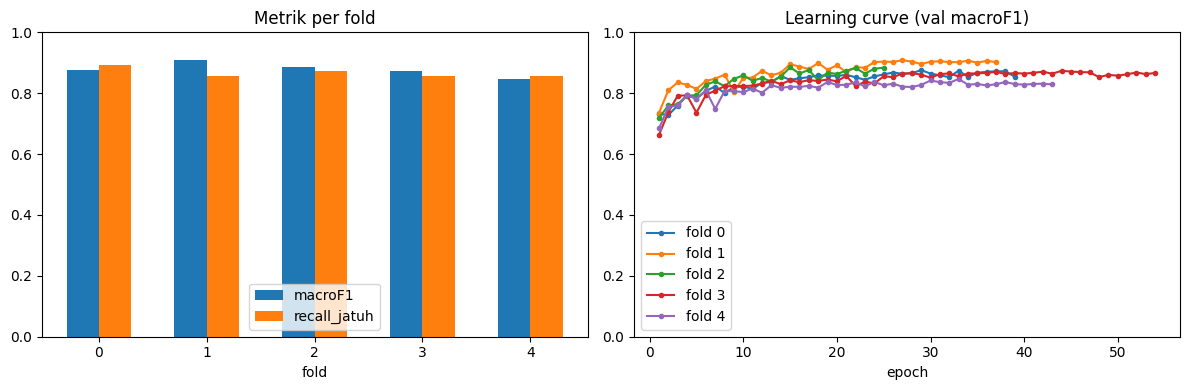

Tersimpan: fall_cv_folds.csv, fall_cv_history.csv, fall_cv_summary.json, fall_cv_curves.png


In [ ]:

# ===== CELL 5: Hasil CV — tabel per-fold + mean±std + OOF + simpan + grafik =====
fold_df = pd.DataFrame(fold_metrics)
print("=== Metrik per FOLD ===")
print(fold_df.to_string(index=False))

summary = {k: {"mean": round(float(fold_df[k].mean()), 4), "std": round(float(fold_df[k].std(ddof=0)), 4)}
           for k in METRIC_COLS}
print("\n=== Ringkasan lintas fold (mean ± std) ===")
for k in METRIC_COLS:
    print(f"  {k:14s}: {summary[k]['mean']:.3f} ± {summary[k]['std']:.3f}")

print("\n=== Evaluasi OUT-OF-FOLD (semua sampel) ===")
cm = confusion_matrix(y, oof_pred, labels=[0, 1, 2])
print("Confusion matrix (baris=asli, kolom=prediksi) [normal, oleng, jatuh]:")
print(cm)
print("\nLaporan per kelas (OOF):")
print(classification_report(y, oof_pred, labels=[0, 1, 2],
                            target_names=CLASS_NAMES, zero_division=0, digits=3))
fa = ((y == 0) & (oof_pred != 0)).sum() / max((y == 0).sum(), 1)
print(f"False-alarm rate OOF (normal -> non-normal): {fa:.3f}")

# simpan
fold_df.to_csv(f"{MODEL_DIR}/fall_cv_folds.csv", index=False)
pd.DataFrame(all_history).to_csv(f"{MODEL_DIR}/fall_cv_history.csv", index=False)
with open(f"{MODEL_DIR}/fall_cv_summary.json", "w") as f:
    json.dump({"n_folds": N_FOLDS, "summary_mean_std": summary,
               "oof_confusion_matrix": cm.tolist(),
               "oof_false_alarm": round(float(fa), 4)}, f, indent=2)

# grafik: (a) metrik kunci per fold, (b) learning curve val macroF1 tiap fold
hist_df = pd.DataFrame(all_history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(fold_df.fold - 0.15, fold_df.macroF1, width=0.3, label="macroF1")
ax[0].bar(fold_df.fold + 0.15, fold_df.recall_jatuh, width=0.3, label="recall_jatuh")
ax[0].set_xlabel("fold"); ax[0].set_ylim(0, 1); ax[0].set_title("Metrik per fold"); ax[0].legend()
for fk in sorted(hist_df.fold.unique()):
    sub = hist_df[hist_df.fold == fk]
    ax[1].plot(sub.epoch, sub.macroF1, marker='.', label=f"fold {fk}")
ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1); ax[1].set_title("Learning curve (val macroF1)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{MODEL_DIR}/fall_cv_curves.png", dpi=120); plt.show()
print(f"Tersimpan: fall_cv_folds.csv, fall_cv_history.csv, fall_cv_summary.json, fall_cv_curves.png")




In [ ]:
# ===== CELL 6: Model FINAL (dilatih di SEMUA data) + simpan bobot & config =====
final_epochs = max(3, int(round(np.mean(best_epochs))))   # panjang latih dari CV
print(f"Melatih model FINAL di semua {N} jendela, {final_epochs} epoch "
      f"(rata-rata best-epoch CV).")
cnt = np.bincount(y, minlength=N_CLASSES).astype(np.float32)
cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
final = FallLSTM(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
crit  = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
opt   = torch.optim.Adam(final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
dl_all = make_loader(np.arange(N), True)
for ep in range(1, final_epochs + 1):
    final.train(); run = 0.0
    pbar = tqdm(dl_all, desc=f"FINAL ep {ep:02d}/{final_epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss = crit(final(xb), yb); loss.backward()
        torch.nn.utils.clip_grad_norm_(final.parameters(), GRAD_CLIP)
        opt.step(); run += loss.item() * len(yb); pbar.set_postfix(loss=f"{loss.item():.4f}")
    print(f"  FINAL ep {ep:02d} | train_loss {run/N:.4f}")

BEST_PATH = f"{MODEL_DIR}/fall_head.pt"
torch.save(final.state_dict(), BEST_PATH)
config = {"arch": "FallLSTM", "in_dim": IN_DIM, "hidden": HIDDEN, "layers": LAYERS,
          "dropout": DROPOUT, "n_classes": N_CLASSES, "class_names": CLASS_NAMES,
          "fall_joints": FALL_JOINTS, "use_channels": USE_CHANNELS,
          "window": 45, "stride": 15, "fps": 15, "final_epochs": final_epochs,
          "cv_macroF1": summary["macroF1"], "cv_recall_jatuh": summary["recall_jatuh"],
          "cv_balanced_acc": summary["bal_acc"], "cv_mcc": summary["mcc"],
          "note": "Inferensi: YOLOv8 [T,17,3] -> normalize_pose -> resample_fps(15) "
                  "-> [:,FALL_JOINTS,:2] -> make_windows(45,15) -> model."}
with open(f"{MODEL_DIR}/fall_head.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Model FINAL tersimpan: {BEST_PATH} + fall_head.json")




Melatih model FINAL di semua 23964 jendela, 30 epoch (rata-rata best-epoch CV).


FINAL ep 01/30:   0%|          | 0/188 [00:00<?, ?it/s]

  FINAL ep 01 | train_loss 0.6479


FINAL ep 02/30:   0%|          | 0/188 [00:00<?, ?it/s]

  FINAL ep 02 | train_loss 0.4431


...

  FINAL ep 28 | train_loss 0.0575


FINAL ep 29/30:   0%|          | 0/188 [00:00<?, ?it/s]

  FINAL ep 29 | train_loss 0.0436


FINAL ep 30/30:   0%|          | 0/188 [00:00<?, ?it/s]

  FINAL ep 30 | train_loss 0.0299
Model FINAL tersimpan: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models/fall_head.pt + fall_head.json


In [ ]:
# ===== CELL 7: Efisiensi (params + latency) + baseline + ringkasan =====
n_params = sum(p.numel() for p in final.parameters())
final.eval(); xb = torch.tensor(X[:min(BATCH, N)]).to(DEVICE)
with torch.no_grad():
    for _ in range(3): final(xb)                       # warmup
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(20): final(xb)
    if DEVICE == "cuda": torch.cuda.synchronize()
    ms_per_window = (time.time() - t0) / 20 / xb.shape[0] * 1000
print(f"Efisiensi model  : {n_params:,} parameter | ~{ms_per_window:.3f} ms/jendela ({DEVICE})")

# baseline sebagai lantai pembanding
Xflat = X.reshape(N, -1)
for strat in ["most_frequent", "stratified"]:
    bp = DummyClassifier(strategy=strat, random_state=SEED).fit(Xflat, y).predict(Xflat)
    print(f"Baseline ({strat:13s}) macroF1: "
          f"{f1_score(y, bp, average='macro', zero_division=0):.3f}")

print("\n================ RINGKASAN EKSPERIMEN KEPALA JATUH ================")
print(f"  CV {N_FOLDS}-fold (StratifiedGroup, anti-kebocoran performer)")
print(f"  macroF1      : {summary['macroF1']['mean']:.3f} ± {summary['macroF1']['std']:.3f}")
print(f"  recall_jatuh : {summary['recall_jatuh']['mean']:.3f} ± {summary['recall_jatuh']['std']:.3f}")
print(f"  balanced-acc : {summary['bal_acc']['mean']:.3f} ± {summary['bal_acc']['std']:.3f}")
print(f"  MCC          : {summary['mcc']['mean']:.3f} ± {summary['mcc']['std']:.3f}")
print(f"  model        : {n_params:,} params, ~{ms_per_window:.2f} ms/jendela")
print(f"  vs baseline  : jauh di atas majority (lihat di atas)")
print("  Semua artefak tersimpan di:", MODEL_DIR)
print("  Tip: kalau recall_jatuh kurang, set MONITOR='recall_jatuh' (CELL 1) & latih ulang.")

Efisiensi model  : 554,243 parameter | ~0.037 ms/jendela (cuda)
Baseline (most_frequent) macroF1: 0.260
Baseline (stratified   ) macroF1: 0.340

================ RINGKASAN EKSPERIMEN KEPALA JATUH ================
  CV 5-fold (StratifiedGroup, anti-kebocoran performer)
  macroF1      : 0.878 ± 0.020
  recall_jatuh : 0.867 ± 0.014
  balanced-acc : 0.879 ± 0.023
  MCC          : 0.815 ± 0.031
  model        : 554,243 params, ~0.04 ms/jendela
  vs baseline  : jauh di atas majority (lihat di atas)
  Semua artefak tersimpan di: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models
  Tip: kalau recall_jatuh kurang, set MONITOR='recall_jatuh' (CELL 1) & latih ulang.
